In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

In [3]:
df = pd.read_csv("car_acceptability.csv")
df

,buying price,maintenance cost,number of doors,number of persons,lug_boot,safety,evaluation
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc
...,...,...,...,...,...,...,...
1722,low,low,5,5,med,med,good
1723,low,low,5,5,med,high,vgood
1724,low,low,5,5,big,low,unacc
1725,low,low,5,5,big,med,good


In [4]:
df.head()

,buying price,maintenance cost,number of doors,number of persons,lug_boot,safety,evaluation
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


In [5]:
df.tail()

,buying price,maintenance cost,number of doors,number of persons,lug_boot,safety,evaluation
1722,low,low,5,5,med,med,good
1723,low,low,5,5,med,high,vgood
1724,low,low,5,5,big,low,unacc
1725,low,low,5,5,big,med,good
1726,low,low,5,5,big,high,vgood


In [6]:
df.shape

(1727, 7)

In [7]:
df.isnull()

,buying price,maintenance cost,number of doors,number of persons,lug_boot,safety,evaluation
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
1722,False,False,False,False,False,False,False
1723,False,False,False,False,False,False,False
1724,False,False,False,False,False,False,False
1725,False,False,False,False,False,False,False


In [8]:
df.columns

Index(['buying price', 'maintenance cost', 'number of doors',
       'number of persons', 'lug_boot', 'safety', 'evaluation'],
      dtype='object')

In [9]:
df.describe()

,number of doors,number of persons
count,1727.000000,1727.000000
mean,3.500869,3.667632
std,1.118098,1.247296
min,2.000000,2.000000
25%,3.000000,2.000000
50%,4.000000,4.000000
75%,4.500000,5.000000
max,5.000000,5.000000


In [10]:
df.dtypes

buying price         object
maintenance cost     object
number of doors       int64
number of persons     int64
lug_boot             object
safety               object
evaluation           object
dtype: object

In [11]:
df.nunique()

buying price         4
maintenance cost     4
number of doors      4
number of persons    3
lug_boot             3
safety               3
evaluation           4
dtype: int64

In [12]:
df['evaluation'].unique()

array(['unacc', 'acc', 'vgood', 'good'], dtype=object)

In [13]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1722    False
1723    False
1724    False
1725    False
1726    False
Length: 1727, dtype: bool

In [14]:
df.drop_duplicates()

,buying price,maintenance cost,number of doors,number of persons,lug_boot,safety,evaluation
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc
...,...,...,...,...,...,...,...
1722,low,low,5,5,med,med,good
1723,low,low,5,5,med,high,vgood
1724,low,low,5,5,big,low,unacc
1725,low,low,5,5,big,med,good


In [15]:
le = LabelEncoder()

df['buying price'] = le.fit_transform(df['buying price'])
df['maintenance cost'] =le.fit_transform(df['maintenance cost'])
df['lug_boot']=le.fit_transform(df['lug_boot'])
df['safety']=le.fit_transform(df['safety'])
df['evaluation']=le.fit_transform(df['evaluation'])

In [16]:
X=df.drop("evaluation",axis=1)
Y=df['evaluation']

In [17]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [18]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train,Y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [19]:
Y_pred = rf.predict(X_test)

In [20]:
print("Accuracy:", accuracy_score(Y_test, Y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, Y_pred))

Accuracy: 0.9624277456647399

Confusion Matrix:
 [[ 72   1   3   1]
 [  2  10   0   3]
 [  1   0 236   0]
 [  2   0   0  15]]


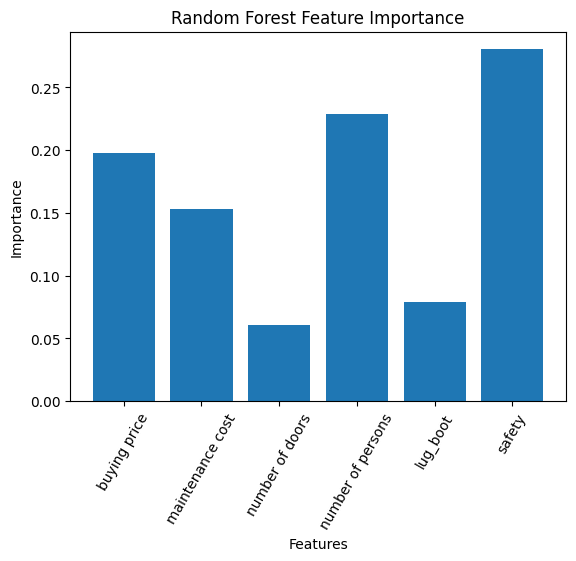

In [21]:
import matplotlib.pyplot as plt 

importance = rf.feature_importances_

plt.bar(X.columns, importance)
plt.xticks(rotation=60)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")
plt.show()